# KPI

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv(r"..\..\Data\clean_data_09-03-2026.csv",parse_dates=['insert_date'])

In [5]:
df.head(5)

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,78,75.0,Malaga,2018-07-31,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,33,52.0,Madrid,2020-01-10,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,148,142.0,Sevilla,2019-07-29,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,292,306.0,Barcelona,2020-01-10,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,36,39.0,Girona,2019-02-19,True


In [6]:
df.groupby('room_type')[['price']].mean()

,price
room_type,
Entire home/apt,1241.612241
Hotel room,1063.030303
Private room,448.238758
Shared room,324.146341


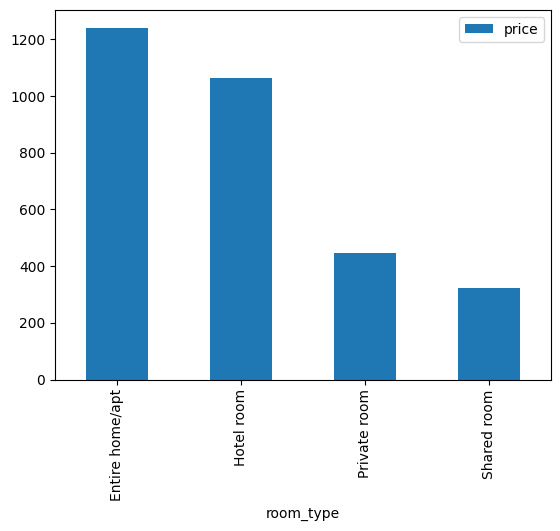

In [7]:
df.groupby('room_type')[['price']].mean().sort_values(by='price',ascending=False).plot.bar();

In [8]:
# KPI General Total de alojamientos

total_alojamientos = len(df)

# KPI General Total de alojamientos
disponibles = df[df['has_availability'] == True].shape[0]

print(f"Total de alojamientos: {total_alojamientos}")
print(f"Alojamientos disponibles: {disponibles}")

Total de alojamientos: 6615
Alojamientos disponibles: 6087


# Pregunta marketing

In [10]:
df['city'].unique()

array(['Malaga', 'Madrid', 'Sevilla', 'Barcelona', 'Girona', 'Valencia',
       'Mallorca', 'Menorca'], dtype=object)

In [6]:
import pandas as pd
import plotly.graph_objects as go

# 1. Preparar los datos y crear rangos de precio
rangos = [0, 500, 1000, 2000, float('inf')]
labels = ['Económico', 'Medio', 'Caro', 'Lujo']
df['price_range'] = pd.cut(df['price'], bins=rangos, labels=labels)

# 2. Definir las columnas que queremos conectar
# Flujo 1: City -> Room Type
# Flujo 2: Room Type -> Price Range
def genSankey(df, cat_cols=[], value_col=''):
    label_list = []
    for col in cat_cols:
        label_list.extend(list(df[col].unique()))
    label_list = list(dict.fromkeys(label_list)) # Eliminar duplicados
    
    source = []
    target = []
    values = []
    
    for i in range(len(cat_cols)-1):
        group = df.groupby([cat_cols[i], cat_cols[i+1]])[value_col].count().reset_index()
        for _, row in group.iterrows():
            source.append(label_list.index(row[cat_cols[i]]))
            target.append(label_list.index(row[cat_cols[i+1]]))
            values.append(row[value_col])
            
    return label_list, source, target, values

# 3. Crear el gráfico
label, source, target, value = genSankey(df, ['city', 'room_type', 'price_range'], 'apartment_id')

fig = go.Figure(data=[go.Sankey(
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = label),
    link = dict(source = source, target = target, value = value)
)])

fig.update_layout(title_text="Flujo de Alojamientos: Ciudad > Tipo > Rango de Precio", font_size=12)
fig.show()

C:\Users\kytus\AppData\Local\Temp\ipykernel_25528\817125669.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby([cat_cols[i], cat_cols[i+1]])[value_col].count().reset_index()


In [13]:
import plotly.express as px

# 1. Creamos los rangos de precio (si no los habías creado antes)
bins = [0, 100, 300, 700, float('inf')]
labels = ['Económico', 'Medio', 'Caro', 'Lujo']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# 2. Creamos el gráfico Sunburst
fig = px.sunburst(
    df, 
    path=['city', 'room_type', 'price_range'], # El orden de la jerarquía
    values='price',                            # O puedes usar count() si prefieres volumen
    color='city',                              # Colorea cada rama por ciudad
    title="Distribución Jerárquica: Ciudad > Tipo > Precio"
)

# Mejoramos un poco la estética
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

Comparativa de la media de precios por Room type por ciudad

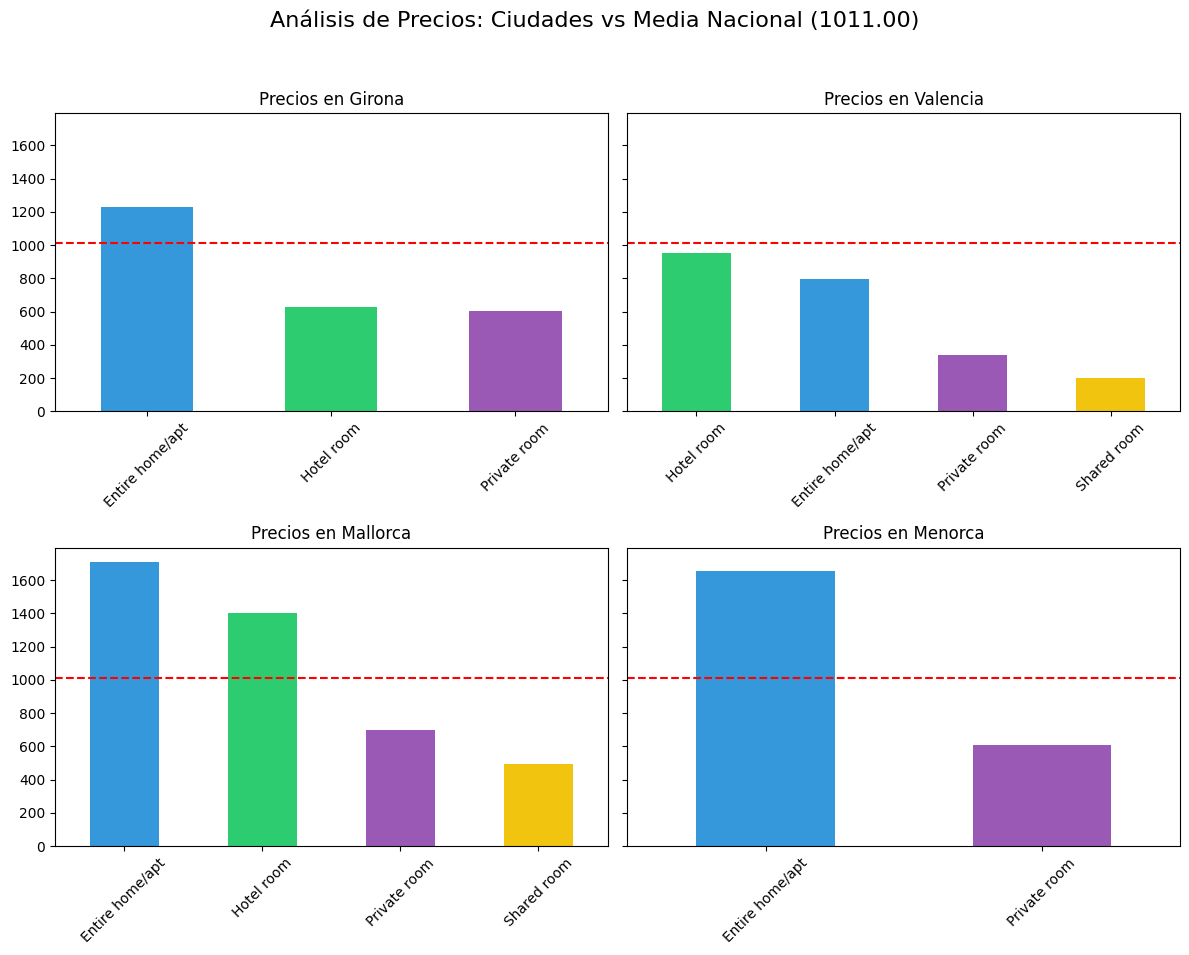

In [17]:
import matplotlib.pyplot as plt

# Anotamos las ciudades a analziar
ciudades = ['Girona', 'Valencia', 'Mallorca', 'Menorca']
# Calculamos la media global de los precios de los alojamientos
media_global = df['price'].mean()

# Definimos un color fijo para cada categoría posible
colores_habitacion = {
    'Entire home/apt': '#3498db', 
    'Private room': '#9b59b6',
    'Hotel room': '#2ecc71', 
    'Shared room': '#f1c40f'
}

# Graficamos 
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):
    # Calculamos los datos del precio por room_type por ciudad.
    stats_ciudad = df[df['city'] == ciudad].groupby('room_type')['price'].mean().sort_values(ascending=False)
    
    # Usamos la variable anterior para los datos y para extraer los colores
    stats_ciudad.plot.bar(
        ax=axes[i], 
        color=[colores_habitacion.get(tipo) for tipo in stats_ciudad.index]
    )
    
    # Agregamos Línea de media global
    axes[i].axhline(media_global, color='red', linestyle='--', linewidth=1.5, label='Media Global')
    
    axes[i].set_title(f'Precios en {ciudad}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Título superior y ajuste de espacio
plt.suptitle(f'Análisis de Precios: Ciudades vs Media Nacional ({media_global:.2f})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\kytus\AppData\Local\Temp\ipykernel_29404\3310046306.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\kytus\AppData\Local\Temp\ipykernel_29404\3310046306.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\kytus\AppData\Local\Temp\ipykernel_29404\3310046306.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\kytus\AppData\Local\Temp\ipykernel_29404\3310046306.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

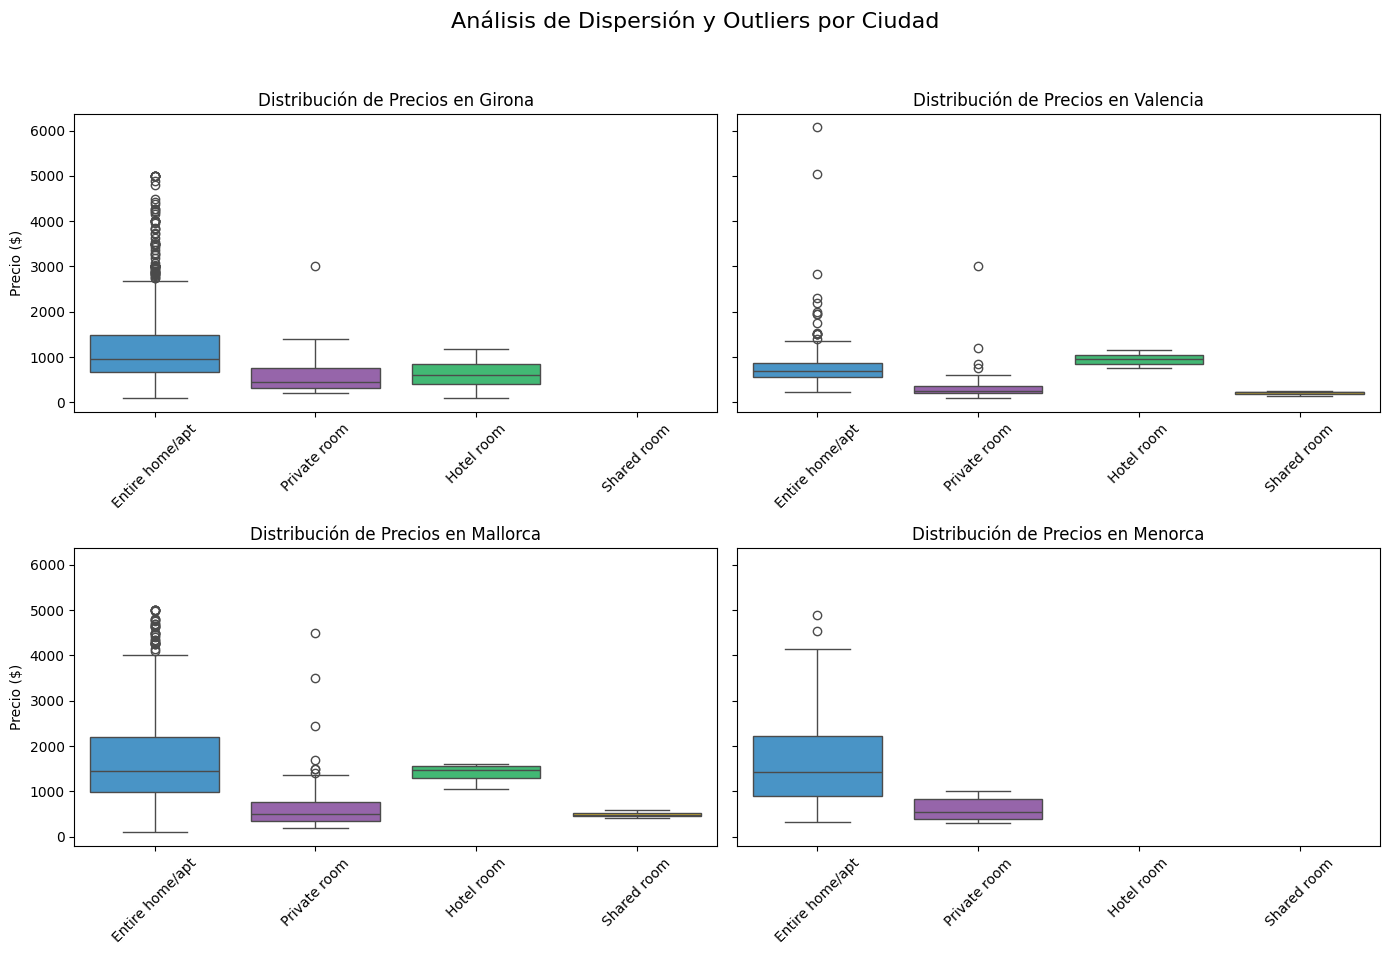

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

ciudades = ['Girona', 'Valencia', 'Mallorca', 'Menorca']

# Creamos la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):
    df_city = df[df['city'] == ciudad]
    
    # Dibujamos el boxplot
    sns.boxplot(
        data=df_city, 
        x='room_type', 
        y='price', 
        ax=axes[i],
        palette=colores_habitacion, # Usamos tus mismos colores
        order=['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'] # Orden fijo
    );
    
    axes[i].set_title(f'Distribución de Precios en {ciudad}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    if i % 2 == 0: axes[i].set_ylabel('Precio ($)')

plt.suptitle('Análisis de Dispersión y Outliers por Ciudad', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Comparativa global de medias y mediana

In [19]:
import plotly.express as px

# 1. Agrupamos (tu código base)
df_mean = df.groupby('room_type')['price'].mean().reset_index()

# 2. Calculamos los estadísticos globales
media_total = df['price'].mean()
mediana_total = df['price'].median()

# 3. Creamos el gráfico
fig = px.bar(df_mean, x='room_type', y='price', 
             title="Precio por Tipo de Habitación vs Métricas Globales",
             labels={'price': 'Precio ($)', 'room_type': 'Tipo de Habitación'})

# 4. Añadimos la línea de la MEDIA
fig.add_hline(y=media_total, 
              line_dash="dot", 
              line_color="red",
              annotation_text=f"Media: {media_total:.2f}", 
              annotation_position="top left")

# 5. Añadimos la línea de la MEDIANA
fig.add_hline(y=mediana_total, 
              line_dash="dash", 
              line_color="green",
              annotation_text=f"Mediana: {mediana_total:.2f}", 
              annotation_position="bottom left")

fig.show()

# Calculo terst ANOVA

In [21]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Imagina que tu dataframe es 'df'
# Columnas: 'precio', 'ciudad', 'tipo_habitacion'

# 1. Definimos el modelo: "El precio depende de la ciudad y el tipo de habitación"
# El '*' significa que queremos ver Ciudad, Tipo y el cruce entre ambos.
modelo = ols('price ~ city * room_type', data=df).fit()

# 2. Calculamos el ANOVA
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

# 3. Vemos el resultado
print(tabla_anova)

                      sum_sq      df            F         PR(>F)
city            3.922249e+08     7.0   106.961623  6.476666e-109
room_type       1.662177e+09     3.0  1057.662148  2.699245e-215
city:room_type  4.256478e+07    21.0     3.869207   5.788029e-08
Residual        3.450094e+09  6586.0          NaN            NaN


c:\Users\kytus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 7, but rank is 5

c:\Users\kytus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1

c:\Users\kytus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 21, but rank is 18



Aqui el ANOVA nos indica que el room type es la variable mas influyente para el cambio de precio, al tener el Estadistico F mas alto de todos (y muy lejos de 1) y un p-valor muy bajo
la ciudad influye, pero menos, lo vemos en que el estadistico F es unas 10 veces menor


# Cálculo test Tukey

In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Comparación por Tipo de Habitación
tukey_habitacion = pairwise_tukeyhsd(endog=df['price'],     # Variable cuantitativa
                                     groups=df['room_type'], # Grupos a comparar
                                     alpha=0.05)            # Nivel de confianza

print(tukey_habitacion)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1        group2     meandiff p-adj    lower      upper   reject
-------------------------------------------------------------------------
Entire home/apt   Hotel room -178.5819 0.5414  -522.6638     165.5  False
Entire home/apt Private room -793.3735    0.0  -847.2906 -739.4564   True
Entire home/apt  Shared room -917.4659    0.0 -1226.4212 -608.5106   True
     Hotel room Private room -614.7915    0.0  -960.6803 -268.9028   True
     Hotel room  Shared room  -738.884 0.0002 -1199.5198 -278.2482   True
   Private room  Shared room -124.0924 0.7345  -435.0587  186.8739  False
-------------------------------------------------------------------------


Vemos que Entire home es mas caro que hotel, private room y shared room (todos meandiff son negativos)
Private y Shared son mas barato que Hotel
Private es mas caro que Shared

- El test da por igual de caro Hotel y ENtire home
- El test da igual de barato private y shared

La diferencia más crítica se da al pasar de un apartamento entero a una habitación privada, con un ahorro medio de 793,37€, lo que explica la gran dispersión y los outliers detectados en el análisis inicial

c:\Users\kytus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning:

The integral is probably divergent, or slowly convergent.



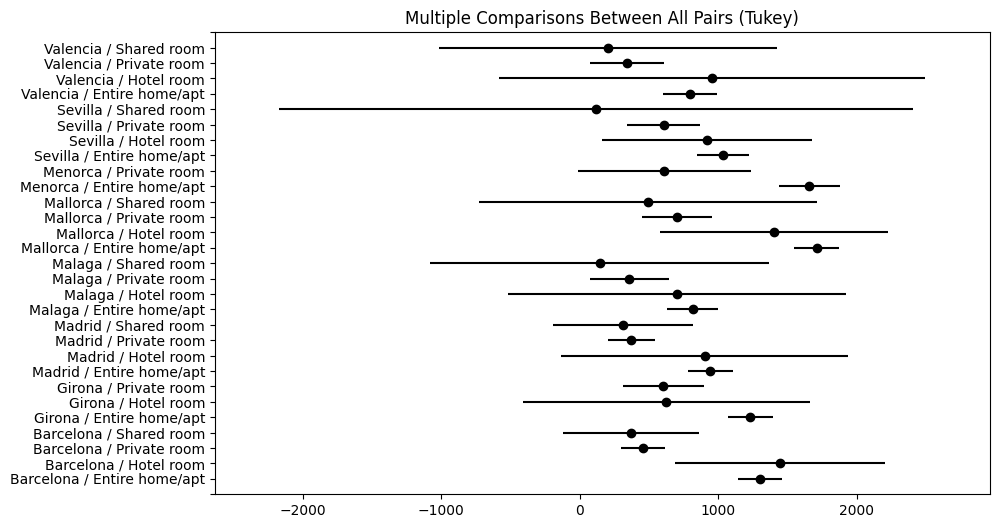

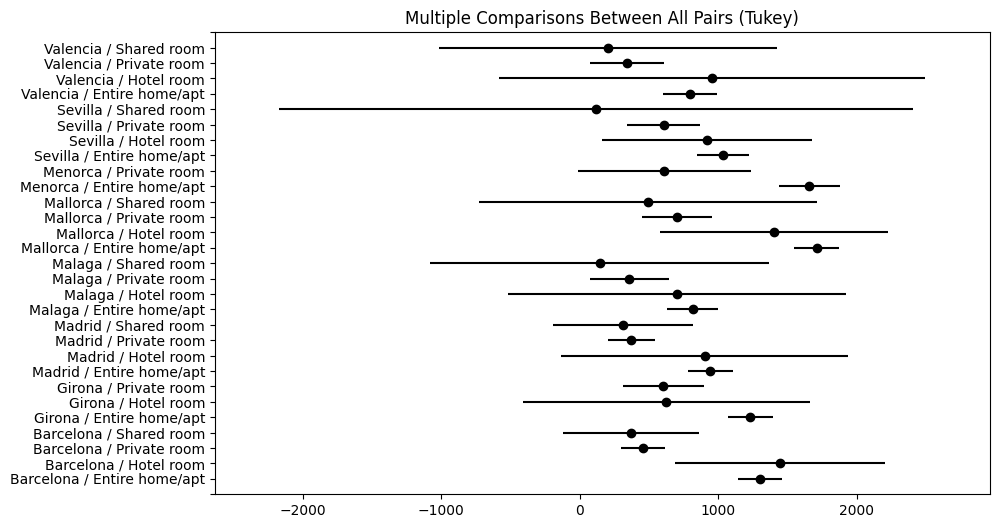

In [23]:
# Creamos una etiqueta combinada
df['combinacion'] = df['city'] + " / " + df['room_type']

# Hacemos el Tukey con esa nueva columna
tukey_total = pairwise_tukeyhsd(endog=df['price'], 
                                groups=df['combinacion'], 
                                alpha=0.05)

# Esto generará una tabla MUY larga, mejor graficarlo:
tukey_total.plot_simultaneous()

- El punto es la media estimada
- la línea es el margen de error
- como mas larga es la línea indica que hay mucha variedad de precios. 
- Las lineas mas largas se pueden dar tambien porque hay pocos datos (la mayoria de casos con Shared room y Hotel)
